In [21]:
import numpy as np
import pandas as pd

In [22]:
df= pd.read_csv("task2.csv")
df.head(30)

,Customer_ID,Age,Gender,City,Education,Employment_Status,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week,Purchased
0,C0071,57.0,Male,Lahore,Master,Unemployed,16.0,1115000.0,23500.0,5.0,15.3,No
1,C0282,56.0,Female,Islamabad,Bachelor,Employed,3.0,655000.0,32300.0,7.0,6.8,No
2,C0284,57.0,Female,Peshawar,Master,Employed,13.0,983000.0,54800.0,7.0,15.1,Yes
3,C0034,44.0,Female,Karachi,PhD,Employed,22.0,839000.0,29200.0,9.0,8.3,Yes
4,C0043,20.0,Female,Islamabad,Bachelor,Employed,NaN,979000.0,49300.0,5.0,7.0,No
5,C0078,35.0,Male,Karachi,Bachelor,Unemployed,14.0,1195000.0,16400.0,7.0,15.7,No
6,C0138,61.0,Female,Karachi,Bachelor,Employed,22.0,721000.0,28200.0,4.0,28.6,Yes
7,C0393,66.0,Female,Karachi,PhD,Employed,5.0,1643000.0,48400.0,NaN,4.0,No
8,C0302,18.0,Other,Karachi,Bachelor,Self-employed,27.0,878000.0,11500.0,6.0,13.6,Yes
9,C0350,20.0,Male,Lahore,Master,Unemployed,14.0,852000.0,49700.0,7.0,19.3,No


In [23]:
df.dtypes

,0
Customer_ID,object
Age,float64
Gender,object
City,object
Education,object
Employment_Status,object
Experience_Years,float64
Annual_Income,float64
Monthly_Spending,float64
Satisfaction_Score,float64


In [24]:
df.shape


(403, 12)

In [25]:
df.isnull().sum()

,0
Customer_ID,0
Age,18
Gender,0
City,0
Education,0
Employment_Status,0
Experience_Years,15
Annual_Income,22
Monthly_Spending,30
Satisfaction_Score,13


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df.duplicated().sum()

np.int64(3)

In [28]:
(df.isnull().sum() / len(df)) * 100

,0
Customer_ID,0.000000
Age,4.466501
Gender,0.000000
City,0.000000
Education,0.000000
Employment_Status,0.000000
Experience_Years,3.722084
Annual_Income,5.459057
Monthly_Spending,7.444169
Satisfaction_Score,3.225806


In [29]:
df = df.drop_duplicates()

In [30]:
df.duplicated().sum()

np.int64(0)

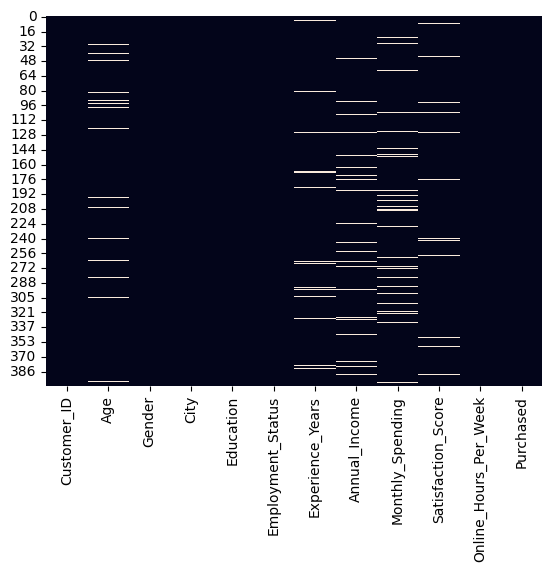

In [31]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [32]:
df[df.duplicated()]

,Customer_ID,Age,Gender,City,Education,Employment_Status,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week,Purchased


In [33]:
df = df.drop_duplicates()

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df["Income_Missing"] = df["Annual_Income"].isnull()

In [36]:
pd.crosstab(
    df["Employment_Status"],
    df["Income_Missing"],
    normalize="index"
) * 100

Income_Missing,False,True
Employment_Status,,
Employed,100.000000,0.000000
Self-employed,100.000000,0.000000
Student,65.079365,34.920635
Unemployed,100.000000,0.000000


In [37]:
df["Satisfaction_Missing"] = df["Satisfaction_Score"].isnull()

pd.crosstab(
    df["Satisfaction_Missing"],
    df["Purchased"],
    normalize="index"
) * 100

Purchased,No,Yes
Satisfaction_Missing,,
False,52.061856,47.938144
True,50.000000,50.000000


In [38]:
df.select_dtypes(include=np.number).columns

Index(['Age', 'Experience_Years', 'Annual_Income', 'Monthly_Spending',
       'Satisfaction_Score', 'Online_Hours_Per_Week'],
      dtype='object')

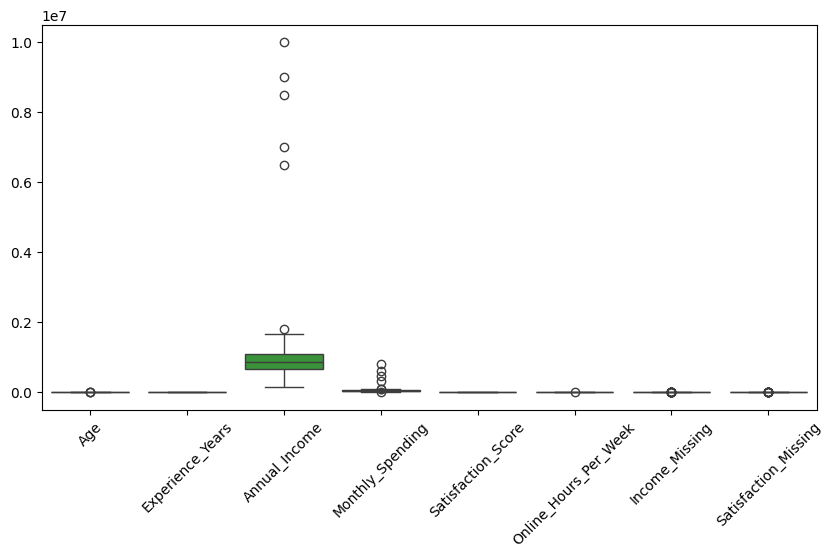

In [39]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.show()

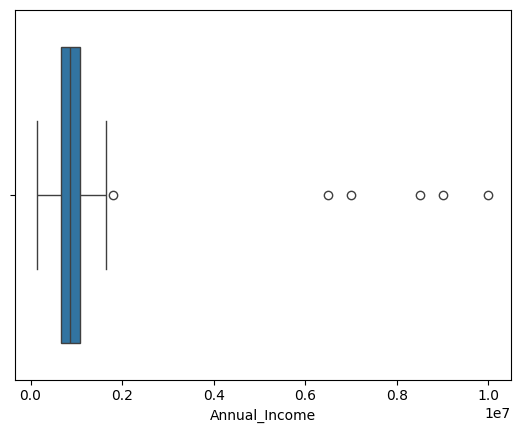

In [40]:
sns.boxplot(x=df["Annual_Income"])
plt.show()

In [41]:
Q1 = df["Annual_Income"].quantile(0.25)
Q3 = df["Annual_Income"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df["Annual_Income"] < lower) |
    (df["Annual_Income"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 6


In [42]:
numeric_cols = [
    "Age",
    "Experience_Years",
    "Annual_Income",
    "Monthly_Spending",
    "Satisfaction_Score",
    "Online_Hours_Per_Week"
]

In [43]:
df["Age"].describe()

,Age
count,382.000000
mean,45.510471
std,18.337565
min,18.000000
25%,32.000000
50%,45.000000
75%,57.000000
max,200.000000


In [44]:
df[df["Age"] > 100]

,Customer_ID,Age,Gender,City,Education,Employment_Status,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week,Purchased,Income_Missing,Satisfaction_Missing
50,C0146,150.0,Male,Multan,Master,Employed,12.0,910000.0,32800.0,6.0,22.3,No,False,False
195,C0087,120.0,Male,Peshawar,Bachelor,Unemployed,8.0,870000.0,38100.0,6.0,17.2,No,False,False
353,C0089,200.0,Female,Islamabad,High School,Unemployed,25.0,995000.0,47100.0,10.0,27.7,No,False,False


In [45]:
df[df["Experience_Years"] < 0]

,Customer_ID,Age,Gender,City,Education,Employment_Status,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week,Purchased,Income_Missing,Satisfaction_Missing
118,C0061,64.0,Male,Karachi,High School,Employed,-3.0,656000.0,23100.0,9.0,5.8,Yes,False,False


In [46]:
df[
    (df["Satisfaction_Score"] < 1) |
    (df["Satisfaction_Score"] > 10)
]

,Customer_ID,Age,Gender,City,Education,Employment_Status,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week,Purchased,Income_Missing,Satisfaction_Missing
314,C0041,NaN,Male,Karachi,Master,Employed,23.0,545000.0,25600.0,15.0,24.8,Yes,False,False


In [47]:
df[df["Monthly_Spending"] < 0]

,Customer_ID,Age,Gender,City,Education,Employment_Status,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week,Purchased,Income_Missing,Satisfaction_Missing
102,C0076,21.0,Male,Peshawar,Master,Self-employed,8.0,624000.0,-5000.0,1.0,27.3,No,False,False


In [48]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [49]:
numeric_cols = [
    "Age",
    "Experience_Years",
    "Annual_Income",
    "Monthly_Spending",
    "Satisfaction_Score",
    "Online_Hours_Per_Week"
]

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [50]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
City,0
Education,0
Employment_Status,0
Experience_Years,0
Annual_Income,0
Monthly_Spending,0
Satisfaction_Score,0


In [51]:
df.select_dtypes(include="object").columns

Index(['Customer_ID', 'Gender', 'City', 'Education', 'Employment_Status',
       'Purchased'],
      dtype='object')

In [52]:
df = pd.get_dummies(
    df,
    columns=["Gender", "City", "Education", "Employment_Status"],
    drop_first=True
)

In [53]:
df.head(30)

,Customer_ID,Age,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week,Purchased,Income_Missing,Satisfaction_Missing,...,City_Lahor,City_Lahore,City_Multan,City_Peshawar,Education_High School,Education_Master,Education_PhD,Employment_Status_Self-employed,Employment_Status_Student,Employment_Status_Unemployed
0,C0071,57.0,16.0,1115000.0,23500.0,5.0,15.3,No,False,False,...,False,True,False,False,False,True,False,False,False,True
1,C0282,56.0,3.0,655000.0,32300.0,7.0,6.8,No,False,False,...,False,False,False,False,False,False,False,False,False,False
2,C0284,57.0,13.0,983000.0,54800.0,7.0,15.1,Yes,False,False,...,False,False,False,True,False,True,False,False,False,False
3,C0034,44.0,22.0,839000.0,29200.0,9.0,8.3,Yes,False,False,...,False,False,False,False,False,False,True,False,False,False
4,C0043,20.0,16.0,979000.0,49300.0,5.0,7.0,No,False,False,...,False,False,False,False,False,False,False,False,False,False
5,C0078,35.0,14.0,1195000.0,16400.0,7.0,15.7,No,False,False,...,False,False,False,False,False,False,False,False,False,True
6,C0138,61.0,22.0,721000.0,28200.0,4.0,28.6,Yes,False,False,...,False,False,False,False,False,False,False,False,False,False
7,C0393,66.0,5.0,1643000.0,48400.0,6.0,4.0,No,False,True,...,False,False,False,False,False,False,True,False,False,False
8,C0302,18.0,27.0,878000.0,11500.0,6.0,13.6,Yes,False,False,...,False,False,False,False,False,False,False,True,False,False
9,C0350,20.0,14.0,852000.0,49700.0,7.0,19.3,No,False,False,...,False,True,False,False,False,True,False,False,False,True


In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
numeric_cols = [
    "Age",
    "Experience_Years",
    "Annual_Income",
    "Monthly_Spending",
    "Satisfaction_Score",
    "Online_Hours_Per_Week"
]

In [56]:
scaler = StandardScaler()

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [57]:
df.shape

(400, 24)

In [58]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Experience_Years,0
Annual_Income,0
Monthly_Spending,0
Satisfaction_Score,0
Online_Hours_Per_Week,0
Purchased,0
Income_Missing,0
Satisfaction_Missing,0


In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.dtypes

,0
Customer_ID,object
Age,float64
Experience_Years,float64
Annual_Income,float64
Monthly_Spending,float64
Satisfaction_Score,float64
Online_Hours_Per_Week,float64
Purchased,object
Income_Missing,bool
Satisfaction_Missing,bool


In [61]:
df.describe()

,Age,Experience_Years,Annual_Income,Monthly_Spending,Satisfaction_Score,Online_Hours_Per_Week
count,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02,4.000000e+02
mean,1.709743e-16,3.330669e-17,1.554312e-17,8.881784e-18,-9.769963e-17,3.819167e-16
std,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00,1.001252e+00
min,-1.535867e+00,-2.188718e+00,-9.179049e-01,-8.179127e-01,-1.549488e+00,-2.258727e+00
25%,-6.977402e-01,-7.745510e-01,-3.045564e-01,-2.395980e-01,-8.687682e-01,-7.276774e-01
50%,-2.723911e-02,5.037970e-02,-1.130636e-01,-8.626036e-02,1.523110e-01,-1.748828e-03
75%,5.873869e-01,7.574632e-01,1.204432e-01,7.435736e-02,8.330304e-01,7.241797e-01
max,8.633400e+00,1.700241e+00,1.034301e+01,1.383334e+01,3.215548e+00,3.218734e+00
